In [24]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

# TODO


In [25]:
Plin = 1e-16

kappa = 1e6*2*pi
hbar = 6.63e-34/(2*np.pi)
omega_a = 5e9*2*np.pi

chi = 0.5e6*2*pi

nbar = 4*Plin/(hbar*omega_a*kappa)*np.exp(-(np.sqrt(3)*chi/kappa)**2)
print(nbar)

A = np.sqrt(Plin/(hbar*omega_a))
print(A)

9.071429480544309
5492.350363810897


In [26]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('sqrtka_ext', np.sqrt(kappa)) # in MHz
sim.add_param('ka_int', 0e6*2*pi) # in MHz
sim.add_param('K', 0e6 * 2 * np.pi)
sim.add_param('amplR',  A)
sim.add_param('wa', 0.00e9*2*pi)
# sim.add_paramsweep('wa', 4.99e9*2*pi, 5.01e9*2*pi, 101)  #this simulates a slow dephasing effect
sim.add_param('wR', 0.0e9 * 2 * np.pi, is_excitation=True)
sim.add_param('rampR', 30e-9)
sim.add_param('startR', 100e-9)
sim.add_param('stopR', 6000e-9)
sim.add_param('phaseR', 0)
sim.add_paramsweep('sigma_Z', -1, 1, 2)
sim.add_param('chi', chi)


Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('ain', '0', IC_str='amplR')

sim.add_EOM('a', '-1j*(wa+sigma_Z*chi)*a - ain*sqrtka_ext - (sqrtka_ext**2 + ka_int)/2*a - 1j*a*K*abs(a)**2', IC_str='0')
sim.set_solve_type('all')

sim.specify_time(t_f=10e-6, pts=1001)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


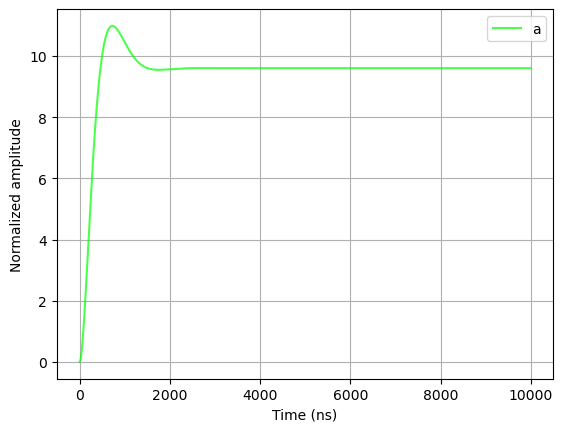

In [20]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
# plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, np.abs(x[2,:]+1j*x[3,:])**2,color=(0,1,0,0.7),label='a')
# plt.plot(t*1e9, ,color=(0,1,0,0.7),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [23]:
x, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:00<00:00, 2262.02it/s]

 
...finished GPU solve!


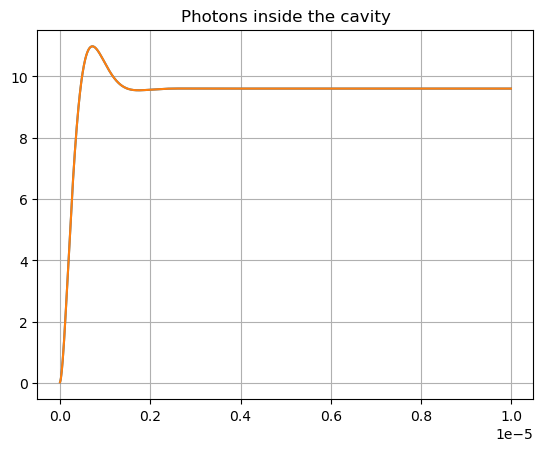

In [22]:
xd = x.copy()
td = t.copy()

ain = xd[0,:]+1j*xd[1,:]
a = xd[2,:]+1j*xd[3,:]

kappa = (sim.param_dict['sqrtka_ext'])**2

aout = ain + np.sqrt(kappa)*a

plt.plot(t[0,:], np.abs(a[0,:])**2)
plt.plot(t[0,:], np.abs(a[1,:])**2)
plt.title('Photons inside the cavity')
plt.grid()
plt.show()

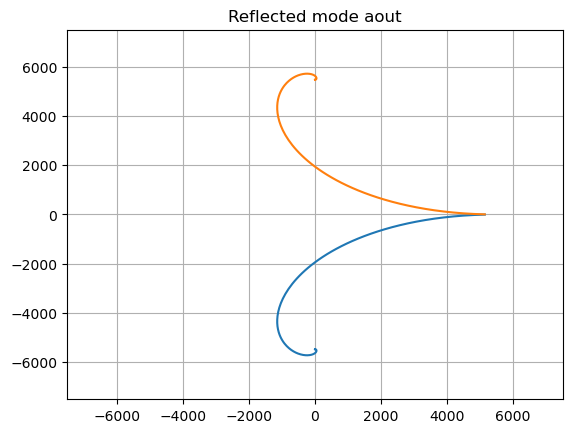

In [637]:
sigma_Z = sim.paramsweep_dict['sigma_Z']

aout_g = aout[0,:]
aout_e = aout[1,:]

plt.plot(np.real(aout_g),np.imag(aout_g))
plt.plot(np.real(aout_e),np.imag(aout_e))
plt.xlim([-3*np.sqrt(kappa),3*np.sqrt(kappa)])
plt.ylim([-3*np.sqrt(kappa),3*np.sqrt(kappa)])
plt.grid()
plt.title('Reflected mode aout')
plt.show()

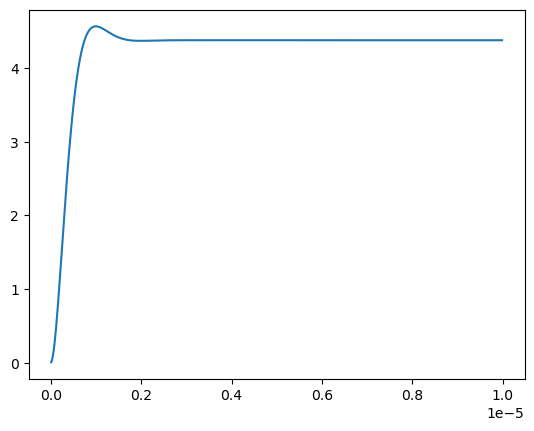

In [639]:
I_t = np.abs(aout_g-aout_e)

plt.plot(t[0,:], I_t/np.sqrt(kappa))
# plt.plot(t[0,:], 2*np.sqrt(nbar)*np.clip((1-np.exp(-(t[0,:])*kappa/2)),0,1))
plt.show()

In [645]:
A_int = I_t*0
for i in range(0, len(I_t)):
    A_int[i] = np.sum(I_t[0:i])*(t[0,1]-t[0,0])

9.071429480544309


C:\Users\boris\AppData\Local\Temp\ipykernel_30344\3853046907.py:7: RuntimeWarning: divide by zero encountered in divide
  Imbarsigma_SS_blais = np.sqrt(8)*A*np.sqrt(t[0,:])*(1 - 2/(kappa*t[0,:])* (1- np.exp(-(kappa*t[0,:]/2))*np.cos(kappa*t[0,:]/2)) )
C:\Users\boris\AppData\Local\Temp\ipykernel_30344\3853046907.py:7: RuntimeWarning: invalid value encountered in multiply
  Imbarsigma_SS_blais = np.sqrt(8)*A*np.sqrt(t[0,:])*(1 - 2/(kappa*t[0,:])* (1- np.exp(-(kappa*t[0,:]/2))*np.cos(kappa*t[0,:]/2)) )
C:\Users\boris\AppData\Local\Temp\ipykernel_30344\3853046907.py:14: RuntimeWarning: invalid value encountered in divide
  Imbarsigma_SS = Imbar_SS/noise
C:\Users\boris\AppData\Local\Temp\ipykernel_30344\3853046907.py:16: RuntimeWarning: invalid value encountered in divide
  plt.plot(t[0,:], Imbar/noise)


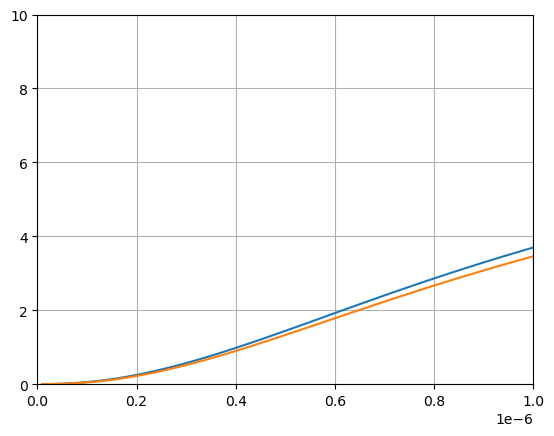

In [667]:
Imbar_SS_1 = np.sqrt(2*nbar)*kappa*t[0,:]*np.abs(np.sin(chi/kappa))

Imbar_SS_2 = np.sqrt(4*kappa)*A*t[0,:]*np.abs(np.sin(chi/kappa))

Imbar = np.sqrt(kappa/4)*A_int

Imbarsigma_SS_blais = np.sqrt(8)*A*np.sqrt(t[0,:])*(1 - 2/(kappa*t[0,:])* (1- np.exp(-(kappa*t[0,:]/2))*np.cos(kappa*t[0,:]/2)) )

print(nbar)

eta = 1
noise = np.sqrt(kappa*t[0,:]/eta)

Imbarsigma_SS = Imbar_SS/noise

plt.plot(t[0,:], Imbar/noise)
# plt.plot(t[0,:], Imbar_SS_1/noise)
# plt.plot(t[0,:], Imbar_SS_2/noise)
plt.plot(t[0,:], Imbarsigma_SS_blais/3) # check out https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.115.203601
plt.xlim([0,1e-6])
plt.ylim([0,10])
plt.grid()
plt.show()

# Dispersive Readout Problem Plot

In [629]:
np.sqrt(8*hbar*omega_a*kappa)

np.float64(1.290852719509095e-08)

In [632]:
4*A**2/kappa

np.float64(19.204216361013014)